# SQLite 归因分析模板

用途：
- 面向 `订单数据` 表做归因分析
- 支持按方向 / 交易对 / 规模分类归因
- 输出 Top 正负贡献项与可视化

In [17]:
import sqlite3  # 导入 SQLite 数据库连接库
import pandas as pd  # 导入 Pandas 用于表格数据处理
import numpy as np  # 导入 NumPy 用于数值计算与空值常量
import matplotlib.pyplot as plt  # 导入 Matplotlib 绘图库
import seaborn as sns  # 导入 Seaborn 统计绘图库

plt.style.use('default')  # 设置 Matplotlib 默认绘图风格
sns.set_theme(style='whitegrid')  # 设置 Seaborn 白底网格主题
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Hiragino Sans GB', 'Heiti SC', 'Arial Unicode MS', 'SimHei']  # 设置中文字体候选列表
plt.rcParams['axes.unicode_minus'] = False  # 修复坐标轴负号显示问题

# 统一显示四位小数（仅影响展示，不改底层数据）
pd.options.display.float_format = '{:.4f}'.format  # 配置 DataFrame 浮点数显示格式

DB_PATH = '/Users/yy/.openclaw/workspace/db/orders.db'  # 定义目标 SQLite 数据库路径
conn = sqlite3.connect(DB_PATH)  # 建立数据库连接对象
print('Connected:', DB_PATH)  # 打印连接成功信息

Connected: /Users/yy/.openclaw/workspace/db/orders.db


In [18]:
def clean_numeric_series(s: pd.Series) -> pd.Series:  # 定义数值清洗函数，将字符串列安全转为数值列
    return pd.to_numeric(  # 使用 Pandas 统一做数值转换
        s.astype(str)  # 先强制转字符串，避免混合类型报错
         .str.strip()  # 去除首尾空白字符
         .str.replace(',', '', regex=False)  # 去除千分位逗号
         .str.replace('%', '', regex=False)  # 去除百分号
         .str.replace('U', '', regex=False)  # 去除金额单位 U
         .replace({'': None, '-': None, '--': None, 'None': None, 'nan': None}),  # 统一常见空值占位
        errors='coerce'  # 无法转换的值强制置为 NaN
    )  # 返回清洗后的数值 Series

def first_existing(cols, cands):  # 定义工具函数：返回候选字段中第一个存在的列名
    return next((c for c in cands if c in cols), None)  # 若无命中则返回 None

In [19]:
# 1) 选择订单表 + 日期范围  # 本步骤用于确定分析目标表和时间窗口
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)  # 查询数据库中全部表名并排序
order_tables = [t for t in tables['name'].tolist() if '订单数据' in t]  # 仅保留包含“订单数据”的业务表
display(pd.DataFrame({'order_tables': order_tables}))  # 展示可选订单表清单

TARGET_TABLE = order_tables[0] if order_tables else None  # 默认选择第一张订单表作为分析目标
START_DATE = '2026-03-01'  # 设置分析起始日期（含当日）
END_DATE = '2099-12-31'  # 设置分析结束日期（含当日）
print('TARGET_TABLE =', TARGET_TABLE)  # 打印最终选择的目标表

,order_tables
0,k1_订单数据_2026_03_27
1,k1_订单数据_2026_03_28
2,k1_订单数据_2026_03_29
3,k1_订单数据_2026_03_31
4,k1_订单数据_2026_04_01
5,k2_订单数据_2026_03_27
6,k2_订单数据_2026_03_28
7,k2_订单数据_2026_03_29
8,k2_订单数据_2026_03_31
9,k2_订单数据_2026_04_01


TARGET_TABLE = k1_订单数据_2026_03_27


In [20]:
# 2) 读取数据  # 按目标表与日期范围从 SQLite 拉取分析数据（自动识别日期列）
if TARGET_TABLE:  # 若存在可用目标表
    schema = pd.read_sql_query(f"PRAGMA table_info('{TARGET_TABLE}')", conn)  # 读取表结构
    cols = schema['name'].tolist()  # 获取字段列表
    date_col = first_existing(cols, ['日期', 'date', 'datetime', 'timestamp', 'time', '创建时间'])  # 自动识别日期列

    if date_col:  # 若识别到日期列
        q = f'''SELECT * FROM "{TARGET_TABLE}" WHERE DATE("{date_col}") >= DATE('{START_DATE}') AND DATE("{date_col}") <= DATE('{END_DATE}')'''  # 按日期过滤
    else:  # 若未识别到日期列
        q = f'''SELECT * FROM "{TARGET_TABLE}"'''  # 不加日期过滤，避免报错

    df = pd.read_sql_query(q, conn)  # 执行 SQL 并读取为 DataFrame
    print('date_col =', date_col)  # 打印识别到的日期列
else:  # 若没有目标表
    df = pd.DataFrame()  # 回退为空 DataFrame，避免后续代码报错

print('shape:', df.shape)  # 打印数据行列规模
display(df.head())  # 展示前 5 行样本供快速检查

date_col = None
shape: (42939, 15)


,单笔盈亏,捆绑费,gas费u,带手续费理论利润,BNB单笔自增长盈亏,稳定币变化量u,交易占比,持仓占比,虚拟持仓占比,交易对类型,交易方向,交易对,稳定币持仓,token持仓,BNB剩余持仓
0,1.74,0.0,0.01,0.02,-1.61,-233.44,0.0,0.0,0.0,v4,买币,USDC>ROBO,21862.78409155774,93741.642293012,32.16123694640142
1,-0.01,0.0,0.01,0.01,0.0,-27.46,0.0,0.0,0.0,v4,买币,USDT>Beat,55110.346385228935,46.76805005520463,32.16123694640142
2,-3.39,0.11,0.01,0.24,0.0,-631.64,0.0,0.0,0.0,v4,买币,USDC>ROBO,21231.141244996496,118874.81112435403,32.16105427850784
3,4.23,0.05,0.01,0.14,-0.96,-451.75,0.0,0.0,0.0,v4,买币,USDT>GWEI,54658.59353124997,45967.1447103146,32.16097170841555
4,-3.04,0.0,0.01,0.08,0.0,-399.4,0.0,0.0,0.0,v4,买币,USDC>ROBO,20924.49162443297,134770.3890501192,32.16097170841555


In [21]:
# 3) 自动识别核心字段  # 从不同命名风格中自动匹配关键分析列
cols = df.columns.tolist()  # 获取当前数据表的全部字段名
pnl_col = first_existing(cols, ['单笔盈亏', 'pnl', 'profit'])  # 识别盈亏列
alpha_col = first_existing(cols, ['alpha', 'alpha利润（跨12）'])  # 识别 alpha 列
slip_col = first_existing(cols, ['slippage'])  # 识别滑点列
side_col = first_existing(cols, ['交易方向', 'side'])  # 识别交易方向列
pair_col = first_existing(cols, ['交易对', 'pair'])  # 识别交易对列
size_col = first_existing(cols, ['稳定币变化量u', '总交易量（跨1）', '总交易量（跨2）'])  # 识别交易规模列

print('pnl_col =', pnl_col)  # 输出盈亏列识别结果
print('alpha_col =', alpha_col)  # 输出 alpha 列识别结果
print('slip_col =', slip_col)  # 输出滑点列识别结果
print('side_col =', side_col)  # 输出方向列识别结果
print('pair_col =', pair_col)  # 输出交易对列识别结果
print('size_col =', size_col)  # 输出规模列识别结果

pnl_col = 单笔盈亏
alpha_col = None
slip_col = None
side_col = 交易方向
pair_col = 交易对
size_col = 稳定币变化量u


In [22]:
# 4) 数值标准化 + 核心总览  # 先清洗关键数值列，再输出整体统计概览
if not df.empty and pnl_col:  # 若数据非空且存在盈亏列
    df[pnl_col] = clean_numeric_series(df[pnl_col])  # 清洗并转换盈亏为数值
if not df.empty and alpha_col:  # 若数据非空且存在 alpha 列
    df[alpha_col] = clean_numeric_series(df[alpha_col])  # 清洗并转换 alpha 为数值
if not df.empty and slip_col:  # 若数据非空且存在滑点列
    df[slip_col] = clean_numeric_series(df[slip_col])  # 清洗并转换滑点为数值
if not df.empty and size_col:  # 若数据非空且存在规模列
    df[size_col] = clean_numeric_series(df[size_col]).abs()  # 清洗规模并取绝对值便于分桶

overview = {  # 组装核心概览指标字典
    'rows': len(df),  # 总行数
    'pnl_sum': df[pnl_col].sum() if pnl_col else np.nan,  # 盈亏累计
    'pnl_mean': df[pnl_col].mean() if pnl_col else np.nan,  # 盈亏均值
    'alpha_sum': df[alpha_col].sum() if alpha_col else np.nan,  # alpha 累计
    'slippage_sum': df[slip_col].sum() if slip_col else np.nan,  # 滑点累计
}  # 概览字典定义结束
display(pd.DataFrame([overview]))  # 以单行表格展示概览

,rows,pnl_sum,pnl_mean,alpha_sum,slippage_sum
0,42939,4233.3500,0.0986,NaN,NaN


,交易方向,count,pnl_sum,pnl_mean
0,stable数据校正买,1,-0.0100,-0.0100
1,stable数据校正卖,1,-0.1200,-0.1200
2,token数据校正买,1,-0.1200,-0.1200
3,token数据校正卖,4,-0.2900,-0.0725
4,买币,21637,-21162.3300,-0.9781
5,卖币,21295,25396.2200,1.1926


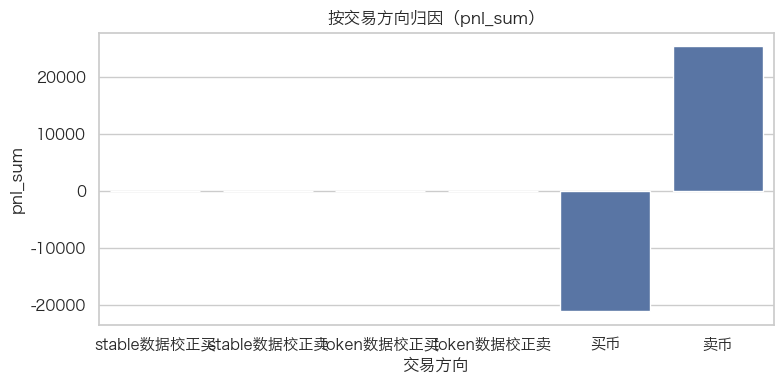

In [23]:
# 5) 方向归因  # 按交易方向聚合统计盈亏表现
if side_col and pnl_col:  # 仅当方向列和盈亏列都存在时执行
    by_side = df.groupby(side_col, as_index=False).agg(  # 使用命名聚合避免列数错位
        count=(pnl_col, 'count'),
        pnl_sum=(pnl_col, 'sum'),
        pnl_mean=(pnl_col, 'mean'),
    )
    display(by_side)  # 展示方向归因统计表

    plt.figure(figsize=(8, 4))  # 创建图表画布
    sns.barplot(data=by_side, x=side_col, y='pnl_sum')  # 绘制方向维度的累计盈亏柱状图
    plt.title('按交易方向归因（pnl_sum）')  # 设置图标题
    plt.tight_layout()  # 自动调整布局避免遮挡
    plt.show()  # 显示图表

,交易对,pnl_sum
29,BSB>USDT,17919.3000
151,USDT>STABLE,2495.0200
34,C>USDT,1544.4500
75,SKYAI>USDT,973.1400
86,TRIA>USDT,861.5800
126,USDT>DEXE,790.0200
39,CYS>USDC,781.5600
88,UB>USDC,585.0700
59,LAB>USDT,533.7700
104,USDC>UB,492.4000


,交易对,pnl_sum
117,USDT>BSB,-17041.0400
78,STABLE>USDT,-2056.4400
154,USDT>TRIA,-902.8200
42,DEXE>USDT,-847.8300
122,USDT>C,-840.7800
150,USDT>SKYAI,-702.7300
153,USDT>TRADOOR,-567.8500
140,USDT>LAB,-472.8400
97,USDC>CYS,-409.2600
130,USDT>FOLKS,-335.1000


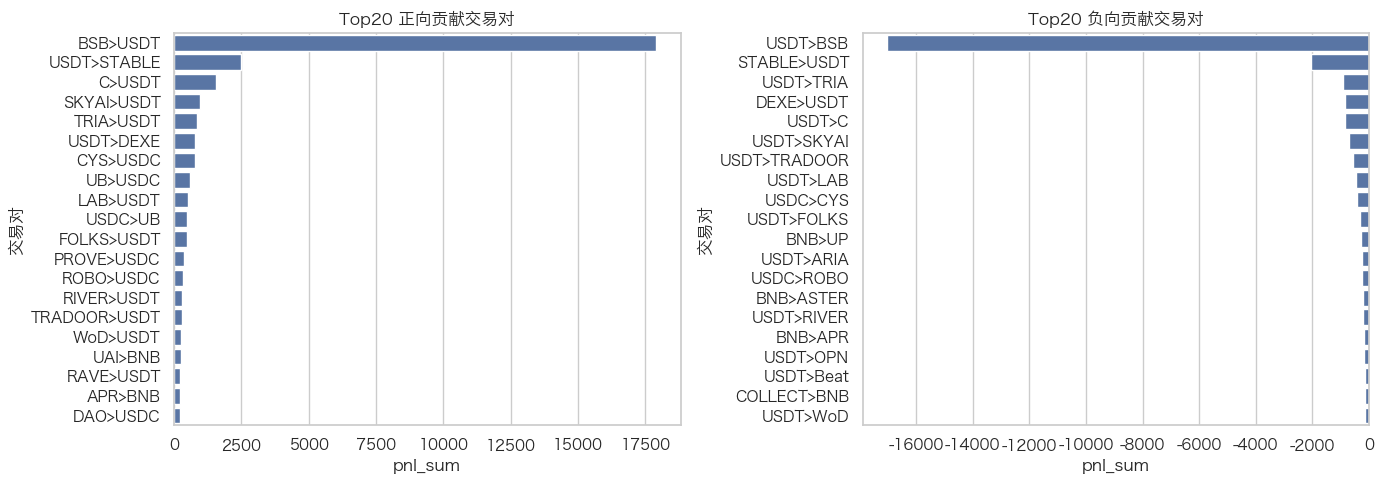

In [24]:
# 6) 交易对归因（Top20 正负贡献）  # 按交易对统计累计盈亏并展示贡献前后 20 名
if pair_col and pnl_col:  # 仅当交易对列和盈亏列都存在时执行
    by_pair = df.groupby(pair_col, as_index=False)[pnl_col].sum().rename(columns={pnl_col: 'pnl_sum'})  # 按交易对汇总累计盈亏
    top_pos = by_pair.sort_values('pnl_sum', ascending=False).head(20)  # 取正向贡献最高的 20 个交易对
    top_neg = by_pair.sort_values('pnl_sum', ascending=True).head(20)  # 取负向贡献最大的 20 个交易对

    display(top_pos)  # 展示正向贡献 Top20 表
    display(top_neg)  # 展示负向贡献 Top20 表

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 创建 1x2 子图用于并排对比
    sns.barplot(data=top_pos, x='pnl_sum', y=pair_col, ax=axes[0])  # 左图绘制正向贡献柱状图
    axes[0].set_title('Top20 正向贡献交易对')  # 设置左图标题
    sns.barplot(data=top_neg, x='pnl_sum', y=pair_col, ax=axes[1])  # 右图绘制负向贡献柱状图
    axes[1].set_title('Top20 负向贡献交易对')  # 设置右图标题
    plt.tight_layout()  # 自动调整布局避免标题和标签重叠
    plt.show()  # 显示图表

,size_bucket,count,pnl_sum,pnl_mean
0,<50,2292,-302.6700,-0.1321
1,50-100,4238,-54.0000,-0.0127
2,100-500,25595,2529.2400,0.0988
3,500-1k,8301,4975.9500,0.5994
4,1k-5k,2500,-2945.3600,-1.1781
5,>5k,13,30.1900,2.3223


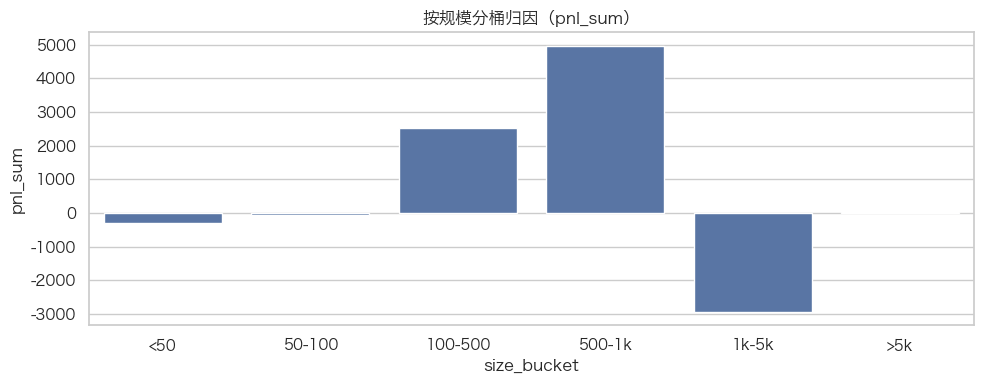

In [25]:
# 7) 规模分桶归因  # 将交易规模按区间分桶后观察各桶盈亏贡献
if size_col and pnl_col:  # 仅当规模列和盈亏列存在时执行
    bins = [0, 50, 100, 500, 1000, 5000, float('inf')]  # 定义规模分桶边界
    labels = ['<50', '50-100', '100-500', '500-1k', '1k-5k', '>5k']  # 定义规模分桶标签
    d = df[[size_col, pnl_col]].dropna().copy()  # 提取规模和盈亏两列并去掉空值行
    d['size_bucket'] = pd.cut(d[size_col], bins=bins, labels=labels, right=False)  # 执行规模分桶

    by_bucket = d.groupby('size_bucket', as_index=False).agg(  # 使用命名聚合避免列数错位
        count=(pnl_col, 'count'),
        pnl_sum=(pnl_col, 'sum'),
        pnl_mean=(pnl_col, 'mean'),
    )
    display(by_bucket)  # 展示规模分桶统计结果

    plt.figure(figsize=(10, 4))  # 创建图表画布
    sns.barplot(data=by_bucket, x='size_bucket', y='pnl_sum')  # 绘制规模桶的累计盈亏柱状图
    plt.title('按规模分桶归因（pnl_sum）')  # 设置图标题
    plt.tight_layout()  # 自动调整布局
    plt.show()  # 显示图表

gap_col = 带手续费理论利润


,gap_bucket,count,pnl_sum,pnl_mean
0,"(-4.091, 0.01]",4834,-672.4900,-0.1391
1,"(0.01, 0.03]",4137,-394.9500,-0.0955
2,"(0.03, 0.07]",4729,496.7700,0.1050
3,"(0.07, 0.11]",4493,34.8400,0.0078
4,"(0.11, 0.13]",3452,-312.6500,-0.0906
5,"(0.13, 0.17]",4937,4109.0800,0.8323
6,"(0.17, 0.22]",3944,658.3400,0.1669
7,"(0.22, 0.32]",3967,266.4300,0.0672
8,"(0.32, 0.56]",4230,1194.5300,0.2824
9,"(0.56, 77.61]",4216,-1146.5500,-0.2720


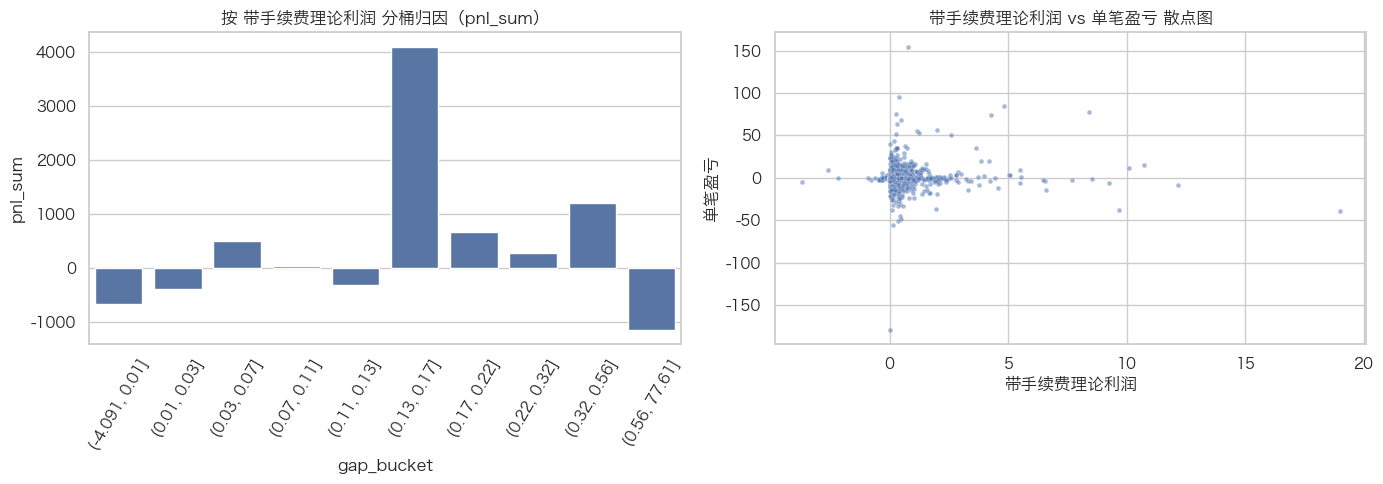

In [26]:
# 8) 价差归因分析（按价差分桶）  # 评估不同价差水平对盈亏贡献的影响
# 说明：优先找“价差”类字段；若没有，则用“带手续费理论利润”作为近似代理  # 兼容不同版本字段命名

gap_col = first_existing(  # 在候选列表中自动识别价差字段
    cols,  # 传入当前数据列名列表
    [  # 定义价差字段候选名
        '价差', 'price_gap', 'price_diff', 'gap', '触发价差', '价差率',  # 常见价差字段名
        '带手续费理论利润'  # 缺省场景下的近似代理字段
    ]  # 候选列表结束
)  # 字段识别结束
print('gap_col =', gap_col)  # 打印识别到的价差列名

if gap_col and pnl_col:  # 若价差列与盈亏列均可用
    g = df[[gap_col, pnl_col]].copy()  # 提取价差与盈亏两列作为分析子集
    g[gap_col] = clean_numeric_series(g[gap_col])  # 清洗并转换价差列为数值
    g[pnl_col] = clean_numeric_series(g[pnl_col])  # 清洗并转换盈亏列为数值
    g = g.dropna()  # 删除价差或盈亏为空的行

    if len(g) >= 20:  # 若有效样本不少于 20 条
        # 用分位数分桶，适配不同量级数据  # 让每个桶样本更均衡
        g['gap_bucket'] = pd.qcut(g[gap_col], q=10, duplicates='drop')  # 按十分位进行自动分桶
        by_gap = g.groupby('gap_bucket', as_index=False).agg(  # 使用命名聚合避免列数错位
            count=(pnl_col, 'count'),
            pnl_sum=(pnl_col, 'sum'),
            pnl_mean=(pnl_col, 'mean'),
        )
        display(by_gap)  # 展示价差分桶统计表

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 创建双子图：柱状图 + 散点图

        sns.barplot(data=by_gap, x='gap_bucket', y='pnl_sum', ax=axes[0])  # 左图绘制各价差桶累计盈亏
        axes[0].set_title(f'按 {gap_col} 分桶归因（pnl_sum）')  # 设置左图标题
        axes[0].tick_params(axis='x', rotation=60)  # 旋转横轴标签避免重叠

        sns.scatterplot(data=g.sample(min(len(g), 3000), random_state=42), x=gap_col, y=pnl_col, s=12, alpha=0.5, ax=axes[1])  # 右图随机抽样绘制价差-盈亏散点关系
        axes[1].set_title(f'{gap_col} vs {pnl_col} 散点图')  # 设置右图标题

        plt.tight_layout()  # 自动调整布局
        plt.show()  # 显示图表
    else:  # 若样本不足
        print('价差有效样本太少，无法稳定分桶')  # 提示样本量不足
else:  # 若未识别到价差列或盈亏列
    print('未找到可用价差列，建议在候选列表中补充字段名')  # 提示补充字段映射

## 可视化增强（综合视图）

以下图表用于把方向、规模、价差归因放在同一视角里观察。

In [ ]:
# A) 方向 + 规模 双图
if 'by_side' in globals() and not by_side.empty and 'by_bucket' in globals() and not by_bucket.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.barplot(data=by_side, x=side_col, y='pnl_sum', ax=axes[0])
    axes[0].set_title('方向归因：累计盈亏')
    axes[0].axhline(0, color='black', linewidth=0.8)

    sns.barplot(data=by_bucket, x='size_bucket', y='pnl_sum', ax=axes[1])
    axes[1].set_title('规模归因：累计盈亏')
    axes[1].tick_params(axis='x', rotation=35)
    axes[1].axhline(0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.show()
else:
    print('请先运行方向归因和规模分桶归因单元。')

In [ ]:
# B) 价差分桶趋势 + 散点（增强版）
if 'by_gap' in globals() and not by_gap.empty and 'g' in globals() and not g.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 左图：价差桶累计盈亏折线（比柱状图更容易看趋势）
    gap_line = by_gap.copy()
    gap_line['bucket_str'] = gap_line['gap_bucket'].astype(str)
    sns.lineplot(data=gap_line, x='bucket_str', y='pnl_sum', marker='o', ax=axes[0])
    axes[0].set_title('价差分桶：累计盈亏趋势')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].axhline(0, color='black', linewidth=0.8)

    # 右图：价差 vs 盈亏散点（抽样）
    sample_n = min(len(g), 3000)
    sns.scatterplot(data=g.sample(sample_n, random_state=42), x=gap_col, y=pnl_col, s=12, alpha=0.45, ax=axes[1])
    axes[1].set_title(f'{gap_col} vs {pnl_col}（抽样{sample_n}）')
    axes[1].axhline(0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.show()
else:
    print('请先运行价差归因分析单元。')

In [27]:
conn.close()  # 关闭 SQLite 连接释放系统资源
print('SQLite connection closed.')  # 打印连接已关闭提示

SQLite connection closed.
